In [2]:
import spikeinterface as si
import spikeinterface.widgets as sw
from pathlib import Path
import os

import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
import spikeinterface.curation as scur

# recompute qc
from spikeinterface.qualitymetrics.misc_metrics import isi_violations, presence_ratio, amplitude_cutoff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
session = 'behavior_716325_2024-05-31_10-31-14'
sorting_ids = ['highpass', 'bandpass']
sorting_dirs = ['/root/capsule/data/behavior_716325_2024-05-31_10-31-14_sorted-opto-ZS_2024-06-05_03-54-32',
                '/root/capsule/data/behavior_716325_2024-05-31_10-31-14_sorted_bandpass']
curation_dirs = ['/root/capsule/data/behavior_716325_2024-05-31_10-31-14_curated_2024-06-08_01-06-46', 
                '/root/capsule/data/behavior_716325_2024-05-31_10-31-14_bandpass_curation']

In [3]:
stream_name = 'experiment1_Record Node 104#Neuropix-PXI-100.ProbeA_recording1'
curated_sortings = [f + '/curated/' + stream_name for f in sorting_dirs]
curation_jsons = []
for curation_dir in curation_dirs:
    tmp_jsons = []
    for root, dirs, files in os.walk(curation_dir):
        for file in files:
            if file.startswith("curation") and file.endswith(".json"):
                tmp_jsons.append(os.path.join(root, file))
    
    curation_jsons.append(tmp_jsons[0])

In [4]:
curated_sorting_outputs = [si.load_extractor(curated_sorting) for curated_sorting in curated_sortings]
sorting_merged = [None]*len(sorting_dirs)
for sorting_ind, curated_sorting_output in enumerate(curated_sorting_outputs):
    print('Original sorting: ')
    print(curated_sorting_output)
    sorting_merged[sorting_ind] = scur.apply_sortingview_curation(curated_sorting_output, uri_or_json=curation_jsons[sorting_ind])
    print('Merged sorting:')
    print(sorting_merged[sorting_ind])

Original sorting: 
NumpyFolderSorting: 359 units - 1 segments - 30.0kHz
Merged sorting:
MergeUnitsSorting: 281 units - 1 segments - 30.0kHz
Original sorting: 
NumpyFolderSorting: 431 units - 1 segments - 30.0kHz
Merged sorting:
MergeUnitsSorting: 350 units - 1 segments - 30.0kHz


In [5]:
def count_within_range(array1, array2, range_val=2):
    # Sort both arrays
    array1.sort()
    array2.sort()
    
    count = 0
    i, j = 0, 0
    n, m = len(array1), len(array2)
    
    while i < n and j < m:
        if abs(array1[i] - array2[j]) <= range_val:
            count += 1
            i += 1
            j += 1
        elif array1[i] < array2[j]:
            i += 1
        else:
            j += 1
            
    return count

# # Example usage:
# array1 = [1, 5, 9, 12]
# array2 = [2, 6, 8, 11, 15]
# result = count_within_range(array1, array2)
# print(f"The number of integers in array1 that have a number in array2 within 2 units is: {result}")


In [6]:
sorting_1 = curated_sorting_outputs[0]
unit_ids_1 = sorting_1.get_unit_ids()
sorting_2 = curated_sorting_outputs[1]
unit_ids_2 = sorting_2.get_unit_ids()
confusion_matrix = np.zeros((len(unit_ids_1), len(unit_ids_2)))
for ind_1, curr_id_1 in enumerate(unit_ids_1):
    print(curr_id_1)
    curr_spikes_1 = list(sorting_1.get_unit_spike_train(curr_id_1))
    for ind_2, curr_id_2 in enumerate(unit_ids_2):
        curr_spikes_2 = list(sorting_2.get_unit_spike_train(curr_id_2))
        confusion_matrix[ind_1, ind_2] = count_within_range(curr_spikes_1, curr_spikes_2, 3)

savefile = '/root/capsule/scratch/confmax.npy'
np.save(savefile, confusion_matrix)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
31
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
129
133
134
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291


In [7]:
# import data
confusion_matrix_path = r'C:\Users\zhixi\Documents\gitRepositories\sueAnalysis\python\ephys\confmax.npy'
unit_ids_1_path = r'C:\Users\zhixi\Documents\gitRepositories\sueAnalysis\python\ephys\sorting_1.npy'
unit_ids_2_path = r'C:\Users\zhixi\Documents\gitRepositories\sueAnalysis\python\ephys\sorting_2.npy'
unit_label_1_path = r'C:\Users\zhixi\Documents\phyData\behavior_716325_2024-05-31_10-31-14_sorted-opto-ZS_2024-06-05_03-54-32_phy\cluster_decoder_label.tsv'
unit_label_2_path = r'C:\Users\zhixi\Documents\phyData\behavior_716325_2024-05-31_10-31-14_sorted_bandpass_phy\cluster_decoder_label.tsv'
pass_qc_1 = r'C:\Users\zhixi\Documents\phyData\behavior_716325_2024-05-31_10-31-14_sorted-opto-ZS_2024-06-05_03-54-32_phy\cluster_default_qc.tsv'
pass_qc_2 = r'C:\Users\zhixi\Documents\phyData\behavior_716325_2024-05-31_10-31-14_sorted_bandpass_phy\cluster_default_qc.tsv'

confusion_matrix = np.load(confusion_matrix_path)
unit_ids_1 = np.load(unit_ids_1_path)
unit_ids_2 = np.load(unit_ids_2_path)
unit_label_1 = pd.read_csv(unit_label_1_path, sep='\t') 
unit_label_2 = pd.read_csv(unit_label_2_path, sep='\t')
pass_qc_1 = pd.read_csv(pass_qc_1, sep='\t')
pass_qc_2 = pd.read_csv(pass_qc_2, sep='\t')

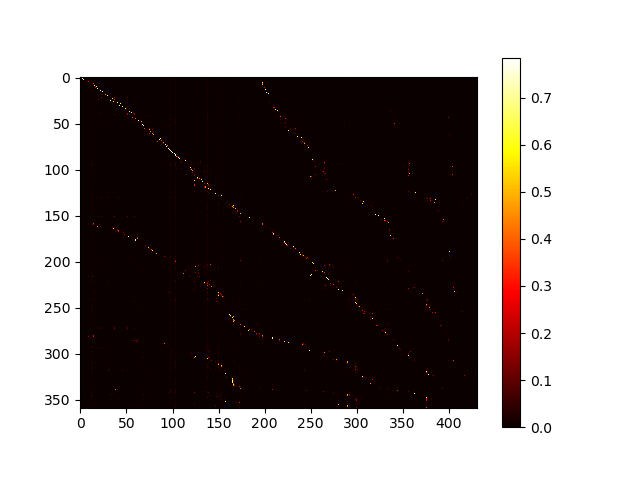

In [40]:
%matplotlib widget
plt.clf()
plt.imshow(confusion_matrix_portion_1, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

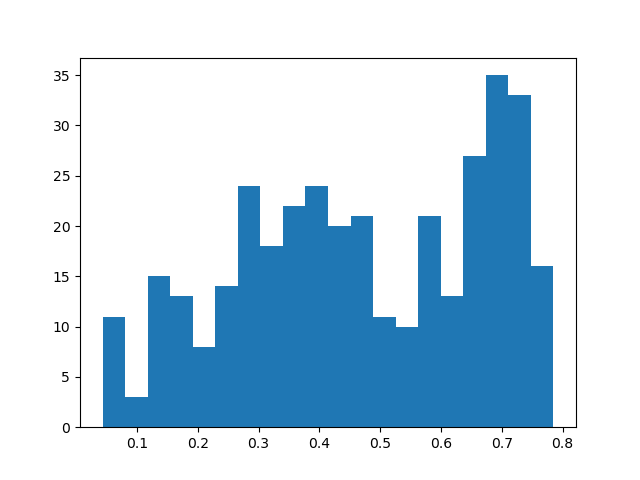

In [30]:
# get portions
total_spikes_1 = np.sum(confusion_matrix, axis=1)
confusion_matrix_portion_1 = confusion_matrix / total_spikes_1[:, None]
# get max portion 
max_portion_1 = np.max(confusion_matrix_portion_1, axis=1)

plt.close()
plt.hist(max_portion_1, bins=20)
plt.show()

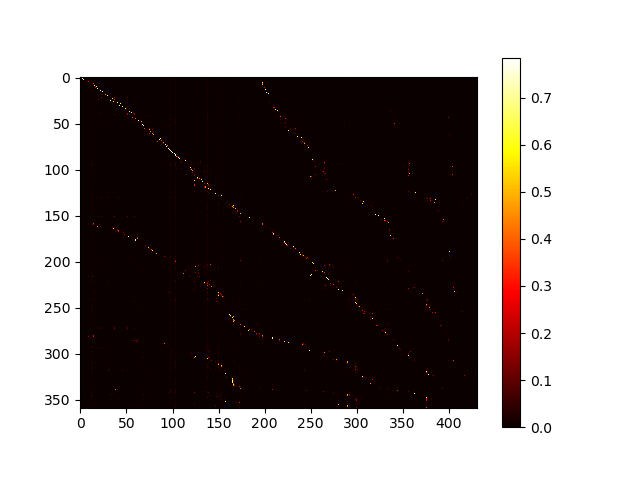

In [31]:
plt.close()
plt.imshow(confusion_matrix_portion_1, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

In [34]:
# clean up noise and artifacts
units_to_keep_1 = unit_label_1.iloc[np.where((unit_label_1['decoder_label'] != 'noise') & (unit_label_1['decoder_label'] != 'artifact'))[0]]['cluster_id']
units_to_keep_2 = unit_label_2.iloc[np.where((unit_label_2['decoder_label'] != 'noise') & (unit_label_2['decoder_label'] != 'artifact'))[0]]['cluster_id']
confusion_matrix_portion_1_clean = confusion_matrix_portion_1[np.where((unit_label_1['decoder_label'] != 'noise') & (unit_label_1['decoder_label'] != 'artifact'))[0], :]
confusion_matrix_portion_1_clean = confusion_matrix_portion_1_clean[:, np.where((unit_label_2['decoder_label'] != 'noise') & (unit_label_2['decoder_label'] != 'artifact'))[0]] 
max_portion_1_clean = np.max(confusion_matrix_portion_1_clean, axis=1)

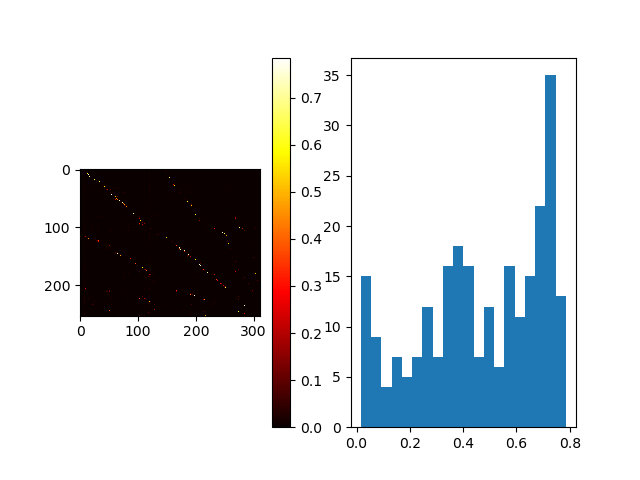

In [36]:
plt.close()
plt.subplot(1, 2, 1)
plt.imshow(confusion_matrix_portion_1_clean, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.hist(max_portion_1_clean, bins=20)
plt.show()

In [10]:
sorting_output.get_property_keys()
sorting_output.get_property('pass_qc')
for segment_index in range(sorting_output.get_num_segments()):
    w = sw.plot_rasters(sorting_output, segment_index=segment_index)
    w.ax.set_title(f"Segment {segment_index}")

NameError: name 'sorting_output' is not defined

In [10]:
units_to_keep = sorting_output.unit_ids[sorting_output.get_property("pass_qc")]
sorting_good = sorting_output.select_units(units_to_keep)
print(f"Original: {sorting_output}")
print(f"Good: {sorting_good}")

AssertionError: renamed_unit_ids must be unique!

In [18]:
sorting_output.get_property_keys()

[]

In [17]:
passqc = sorting_output.get_property("pass_qc")
sorting_output.get_property_keys()

[]

In [ ]:
# get spike trains into a dictionary
spike_trains = {}
segment_index = 0
for unit in sorting_good.unit_ids:
    spike_trains[unit] = sorting_good.get_unit_spike_train(unit, segment_index, return_times=True)

In [ ]:
spike_trains[sorting_good.unit_ids[0]]

In [ ]:
# get alll spikes and labels
all_spikes = sorting_good.get_all_spike_trains()